In [1]:
import gymnasium as gym

In [2]:
import numpy as np
import random

In [3]:
gamma = 0.99
epsilon = 0.1
alpha = 0.5
episodes = 500

In [4]:
# epsilon-policy

def epsilon_greedy(state):
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(Q[state])

In [6]:
Q = np.zeros((48 , 4))

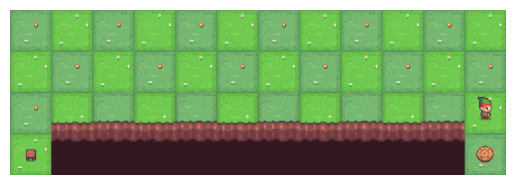

Episode 451/500 | Reward=-13 | Length=13
Episode 452/500 | Reward=-13 | Length=13
Episode 453/500 | Reward=-119 | Length=20
Episode 454/500 | Reward=-15 | Length=15
Episode 455/500 | Reward=-15 | Length=15
Episode 456/500 | Reward=-13 | Length=13
Episode 457/500 | Reward=-13 | Length=13
Episode 458/500 | Reward=-15 | Length=15
Episode 459/500 | Reward=-122 | Length=23
Episode 460/500 | Reward=-124 | Length=25
Episode 461/500 | Reward=-13 | Length=13
Episode 462/500 | Reward=-13 | Length=13
Episode 463/500 | Reward=-15 | Length=15
Episode 464/500 | Reward=-13 | Length=13
Episode 465/500 | Reward=-13 | Length=13
Episode 466/500 | Reward=-15 | Length=15
Episode 467/500 | Reward=-226 | Length=28
Episode 468/500 | Reward=-15 | Length=15
Episode 469/500 | Reward=-544 | Length=49
Episode 470/500 | Reward=-14 | Length=14
Episode 471/500 | Reward=-17 | Length=17
Episode 472/500 | Reward=-13 | Length=13
Episode 473/500 | Reward=-126 | Length=27
Episode 474/500 | Reward=-15 | Length=15
Episode 47

In [9]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

for episode in range(episodes):

    render = (episode % 50 == 0)

    env = gym.make(
        "CliffWalking-v1",
        render_mode="rgb_array" if render else None
    )

    done = False
    state,_ = env.reset()

    episode_len = 0
    tot_reward = 0

    while not done:

        if render:

            clear_output(wait=True)

            frame = env.render()

            plt.imshow(frame)
            plt.axis("off")
            plt.show()

            time.sleep(0.15)

        action = epsilon_greedy(state)

        next_state,reward,terminated,truncated,_ = env.step(action)

        done = terminated or truncated

        # Q-Learning update
        Q[state,action] += alpha * (
            reward
            + gamma*np.max(Q[next_state])
            - Q[state,action]
        )

        state = next_state

        episode_len += 1
        tot_reward += reward

    print(
        f"Episode {episode+1}/{episodes} | "
        f"Reward={tot_reward} | "
        f"Length={episode_len}"
    )

    env.close()

In [10]:
env = gym.make("CliffWalking-v1" , render_mode = "human")
state , _ = env.reset()
total_reward = 0
episode_len = 0
done = False

while not done :
    action = np.argmax(Q[state])
    state , reward , terminated , truncated , _ = env.step(action)
    done = truncated or terminated

    episode_len += 1
    total_reward += reward

print(f"total reward = {total_reward} & episode_len = {episode_len}")
env.close()

total reward = -13 & episode_len = 13
